In [9]:
%pip install scikit-learn pandas


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
%pip install --upgrade matplotlib pandas scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 29.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures

Matplotlib is building the font cache; this may take a moment.


# Model 1: Linear Regression

## 1. Read in Dataset

In [12]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


In [13]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

## 2. Identify Inputs (X) and Output (y)


In [14]:

X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'

# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Linear Regression model:")
X.info()


Information about X columns after cleaning for Linear Regression model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


In [15]:
# X = df[['tempo', 'duration_ms']] # Input
# y = df['popularity'] # Output

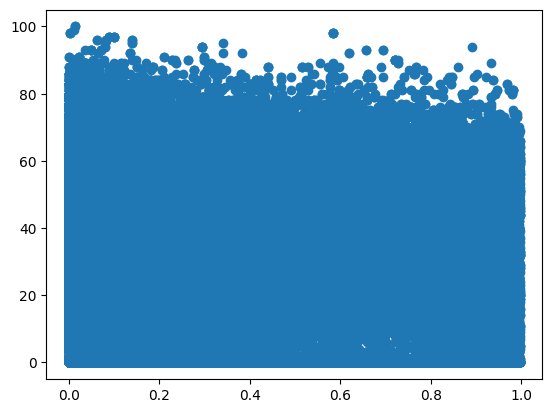

In [16]:

plt.scatter(df['acousticness'],df['popularity'])

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## 3. Train the Model

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Use Model to Predict

In [20]:
model.predict(X_test)

array([34.3895873 , 32.79491118, 31.11603771, ..., 31.38750004,
       35.83388485, 36.70957972], shape=(28500,))

## 5. Scoring our Model

In [21]:
model.score(X_test, y_test)

0.020599953758592693

# Model 2: Random Forest

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html


## 1. Read in Dataset

In [22]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


## 2. Identify Inputs (X) and Output (y)

In [23]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'
# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Random Forest model:")
X.info()


Information about X columns after cleaning for Random Forest model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


## 3. Train the Model


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [25]:
model = RandomForestRegressor()

In [26]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 4. Use Model to Predict


In [27]:
model.predict(X_test)

array([27.48835714, 44.7062807 , 12.20767241, ..., 43.07416667,
       35.32757143, 44.08      ], shape=(28500,))

## 5. Scoring our Model


In [28]:
model.score(X_train, y_train)

0.9026611196456064

# Model 3: Polynomial Regression

## 1. Read in Dataset

In [29]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


## 2. Identify Inputs (X) and Output (y)

In [30]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'

# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Linear Regression model:")
X.info()

Information about X columns after cleaning for Linear Regression model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


## 3. Train the Model

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
poly = PolynomialFeatures(degree = 10)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_poly, y_train)

## 4. Use Model to Predict

In [ ]:
model.predict(X_test_poly)

## 5. Scoring our Model

In [ ]:
model.score(X_test_poly, y_test)

# Model 4: XG Boost

## 1. Read in Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(2)

## 2. Identify Inputs (X) and Output (y)

In [ ]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'
# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Random Forest model:")
X.info()

## 3. Train the Model